In [1]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download(
    "ajitashwath/gaming-addiction-dataset"
)

# Find the first file in the dataset folder
files = os.listdir(path)
print("Files:", files)

file_path = os.path.join(path, files[0])

# Load based on extension
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
elif file_path.endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_path)
elif file_path.endswith(".tsv"):
    df = pd.read_csv(file_path, sep="\t")
else:
    raise ValueError(f"Unsupported file type: {file_path}")



Files: ['gaming_addiction.csv']


In [2]:
df.dtypes

user_id                         object
age                              int64
gender                          object
country                         object
occupation                      object
income_level                    object
years_gaming                     int64
preferred_genre                 object
platform                        object
device_type                     object
rank_tier                       object
daily_playtime_hours           float64
weekly_play_sessions             int64
late_night_sessions_hours      float64
weekend_playtime_hours         float64
consecutive_hours_max          float64
multiplayer_ratio              float64
toxic_chat_reports               int64
rage_quit_frequency              int64
in_game_purchases                int64
monthly_spending_usd           float64
lootbox_openings                 int64
subscription_status             object
stress_score                   float64
loneliness_score               float64
dopamine_dependency_index

In [3]:
df.drop('user_id',axis=1,inplace=True)

In [4]:
df.columns

Index(['age', 'gender', 'country', 'occupation', 'income_level',
       'years_gaming', 'preferred_genre', 'platform', 'device_type',
       'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'subscription_status', 'stress_score',
       'loneliness_score', 'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'relationship_status', 'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'behavioral_cluster', 'addiction_score',


In [5]:
df['churn_probability']

0      1.000
1      0.813
2      0.947
3      0.660
4      0.867
       ...  
245    0.590
246    0.803
247    0.939
248    0.870
249    0.733
Name: churn_probability, Length: 250, dtype: float64

In [6]:

df.drop(columns=['burnout_probability','screen_time_total_hours',
       'late_night_sessions_hours', 'weekend_playtime_hours','weekly_play_sessions',
       'consecutive_hours_max', 'weekend_playtime_hours','age'],inplace=True)

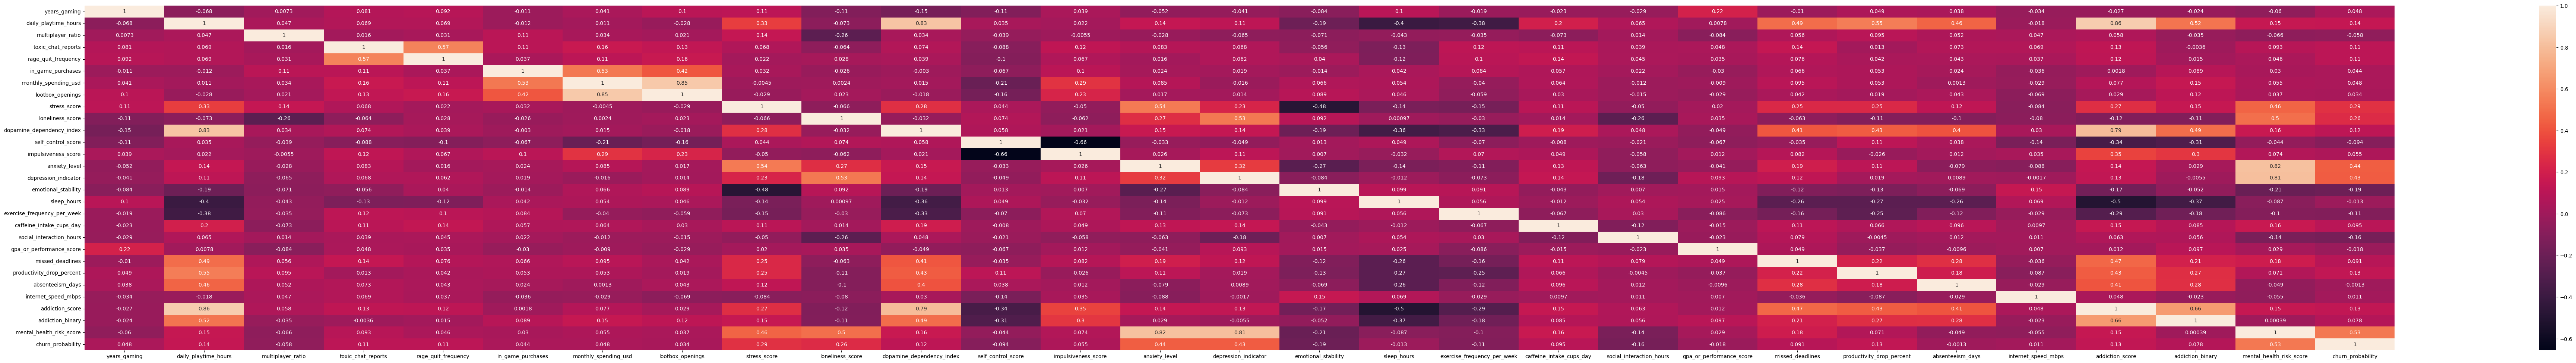

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)
plt.figure(figsize=(100, 12))
sns.heatmap(corr, annot=True)
plt.show()

In [8]:
df.select_dtypes(include=["object"]).columns

Index(['gender', 'country', 'occupation', 'income_level', 'preferred_genre',
       'platform', 'device_type', 'rank_tier', 'subscription_status',
       'relationship_status', 'behavioral_cluster', 'addiction_severity'],
      dtype='object')

In [9]:
d={'High':4, 'Low':0, 'Lower-Middle':1, 'Middle':2, 'Upper-Middle':3}
df['income_level']=df['income_level'].map(d)

In [10]:
import numpy as np
d={'Mild':1, 'Moderate':2, 'Severe':3, np.nan:0}
df['addiction_severity']=df['addiction_severity'].map(d)


In [11]:
d = {
    'Unranked': 0,
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3,
    'Platinum': 4,
    'Diamond': 5,
    'Master': 6,
    'Grandmaster': 7,
    'Legend': 8
}
df['rank_tier']=df['rank_tier'].map(d)

In [12]:
lat_dict = {
    'India': 20.5937,
    'Brazil': -14.2350,
    'South Korea': 35.9078,
    'USA': 37.0902,
    'UK': 55.3781,
    'Canada': 56.1304,
    'France': 46.2276,
    'Germany': 51.1657,
    'Russia': 61.5240,
    'Australia': -25.2744,
    'Indonesia': -0.7893,
    'Mexico': 23.6345,
    'China': 35.8617,
    'Japan': 36.2048,
    'Other': 0.0
}

lon_dict = {
    'India': 78.9629,
    'Brazil': -51.9253,
    'South Korea': 127.7669,
    'USA': -95.7129,
    'UK': -3.4360,
    'Canada': -106.3468,
    'France': 2.2137,
    'Germany': 10.4515,
    'Russia': 105.3188,
    'Australia': 133.7751,
    'Indonesia': 113.9213,
    'Mexico': -102.5528,
    'China': 104.1954,
    'Japan': 138.2529,
    'Other': 0.0
}

df["country_lat"] = df["country"].map(lat_dict)
df["country_lon"] = df["country"].map(lon_dict)

# Optional: remove original country column
df = df.drop(columns=["country"])

In [13]:
pc_dict={'Console':0, 'Mobile':0, 'PC':1, 'PC+Console':1, 'PC+Mobile':1}
mobile_dict={'Console':0, 'Mobile':1, 'PC':0, 'PC+Console':0, 'PC+Mobile':1}
console_dict={'Console':1, 'Mobile':0, 'PC':0, 'PC+Console':1, 'PC+Mobile':0}
df["pc"] = df["platform"].map(pc_dict)
df["mobile"] = df["platform"].map(mobile_dict)
df["console"] = df["platform"].map(console_dict)

df = df.drop(columns=["platform"])

In [14]:
d={'Basic':1, 'Premium':2, 'Ultimate':3, np.nan:0}
df['subscription_status']=df['subscription_status'].map(d)

In [15]:
df.drop('device_type',axis=1,inplace=True)

In [16]:
df.select_dtypes(include=["object"]).columns

Index(['gender', 'occupation', 'preferred_genre', 'relationship_status',
       'behavioral_cluster'],
      dtype='object')

In [17]:
df = pd.get_dummies(
    df,
    columns=[
        'gender',
        'occupation',
        'preferred_genre',
        'relationship_status',
        'behavioral_cluster'
    ],
    drop_first=True,   # common for linear regression
    dtype=int
)
df["depression_indicator"] = df["depression_indicator"].fillna(df["depression_indicator"].median())
df["gpa_or_performance_score"] = (
    df["gpa_or_performance_score"]
    .fillna(df["gpa_or_performance_score"].median())
)

In [18]:
y=df['mental_health_risk_score']
X=df.drop('mental_health_risk_score',axis=1)
X.isnull().sum()

income_level                              0
years_gaming                              0
rank_tier                                 0
daily_playtime_hours                      0
multiplayer_ratio                         0
                                         ..
behavioral_cluster_Competitive Grinder    0
behavioral_cluster_Escape Seeker          0
behavioral_cluster_Social Gamer           0
behavioral_cluster_Streamer/Creator       0
behavioral_cluster_Toxic Competitor       0
Length: 63, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=90)
from sklearn.metrics import mean_squared_error, r2_score


In [20]:
model=LinearRegression()
model.fit(x_train,y_train)
ypred=model.predict(x_test)
print(f"{model} R²:",
      r2_score(y_test, ypred))

LinearRegression() R²: 0.9797304482034257


In [21]:
X2 = X.drop(columns=["depression_indicator"])

x_train, x_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train, y_train)

ypred = model.predict(x_test)

print(f"{model}:R² =", r2_score(y_test, ypred))

LinearRegression():R² = 0.6434575363657883


In [33]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(

max_depth=
)

model.fit(x_train, y_train)

ypred = model.predict(x_test)

print(r2_score(y_test, ypred))

0.1554437305526969
